minimum snr 9.022156497704483
number of pulsars 2014
number of pulsars 2014


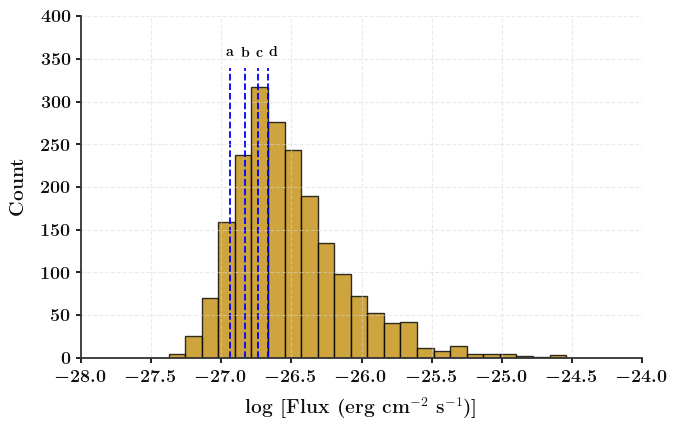

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import pickle
import sys
from psrpoppy import population
import psrpoppy.population as real_population


sys.path.append('path to psrpoppy') # path to psrpoppy
sys.modules['population'] = real_population

-
filename = 'PMSURV.results'
with open(filename, 'rb') as f:
    pop = pickle.load(f)


fluxes = np.array([psr.s_1400() for psr in pop.population]) * (10**-26)
#distances = np.array([psr.dtrue for psr in pop.population]) * 1e3
snr = np.array([psr.snr for psr in pop.population])
print("minimum snr",np.min(snr))
print("number of pulsars", len(fluxes))


df = pd.DataFrame({
    'Flux': fluxes,
    #'Distance': distances,
    'snr': snr
})
print("number of pulsars", len(df))


log_flux = np.log10(df["Flux"])


percentiles = [10, 20, 30,40]
flux_percentiles = np.percentile(df["Flux"],percentiles)
lines = np.log10(flux_percentiles)

labels = [r"$\mathbf{a}$", r"$\mathbf{b}$", r"$\mathbf{c}$",r"$\mathbf{d}$"]

#GLOBAL STYLE
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelweight": "bold",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.linewidth": 1.3,
    "lines.linewidth": 2.5,
    "legend.fontsize": 12,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#111111",
    "xtick.color": "#111111",
    "ytick.color": "#111111",
    "legend.frameon": False,
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})


fig, ax = plt.subplots(figsize=(7, 4.5))


ax.hist(log_flux, bins=24, color="#C28E0E", edgecolor="black", linewidth=1.0, alpha=0.8)


ymin, ymax = ax.get_ylim()  
for x in lines:
    ax.vlines(x, ymin, ymax * 1.02, color="blue", linestyle="--", linewidth=1.3, zorder=1)



y_label_pos = ax.get_ylim()[1] * 0.98
min_spacing = 0.1  
x_positions = lines.copy()

for i in range(1, len(x_positions)):
    if x_positions[i] - x_positions[i - 1] < min_spacing:
        x_positions[i] = x_positions[i - 1] + min_spacing


for x, label in zip(x_positions, labels):
    ax.text(x, y_label_pos, f"{label}",
            ha="center", va="bottom", fontsize=10, color="black", zorder=10)


ax.set_xlabel(r"$\textbf{\text{log [Flux (erg cm$^{-2}$ s$^{-1}$)]}}$",
              labelpad=10, color="#111111")
ax.set_ylabel(r"$\textbf{\text{Count}}$", rotation=90,
              labelpad=10, color="#111111")


x_ticks = ax.get_xticks()
y_ticks = ax.get_yticks()

def bold_tick(t):
    label = f"{t:.1f}".replace("−", "-")
    return rf"$\boldsymbol{{{label}}}$"

def bold_tick_int(t):
    label = f"{int(t)}".replace("−", "-")
    return rf"$\boldsymbol{{{label}}}$"

ax.set_xticks(x_ticks)
ax.set_xticklabels([bold_tick(t) for t in x_ticks])
ax.set_yticks(y_ticks)
ax.set_yticklabels([bold_tick_int(t) for t in y_ticks])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.5)


plt.tight_layout()
plt.savefig("path/flux_histogram_lfl06_ne2001_no_smeared_snr_9_default.pdf", dpi=1000, bbox_inches="tight")
plt.show()
